In [1]:
import sklearn
print(sklearn.__version__)

1.8.0


In [2]:
# custom dataset for pass or fail based on hours studied and exam score using classification from logistic regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
# Create a synthetic dataset
data = {
    'Hours_Studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Exam_Score': [10, 20, 30, 40, 50, 60, 70, 80, 90,np.nan],
    'Result': ["pass" if score >= 50 else "fail" for score in [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]]
}
records = pd.DataFrame(data)

In [3]:
records.head()

,Hours_Studied,Exam_Score,Result
0,1,10.0,fail
1,2,20.0,fail
2,3,30.0,fail
3,4,40.0,fail
4,5,50.0,pass


In [4]:
records.tail()

,Hours_Studied,Exam_Score,Result
5,6,60.0,pass
6,7,70.0,pass
7,8,80.0,pass
8,9,90.0,pass
9,10,NaN,pass


In [5]:
records.describe()

,Hours_Studied,Exam_Score
count,10.00000,9.000000
mean,5.50000,50.000000
std,3.02765,27.386128
min,1.00000,10.000000
25%,3.25000,30.000000
50%,5.50000,50.000000
75%,7.75000,70.000000
max,10.00000,90.000000


In [6]:
records.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Hours_Studied  10 non-null     int64  
 1   Exam_Score     9 non-null      float64
 2   Result         10 non-null     str    
dtypes: float64(1), int64(1), str(1)
memory usage: 372.0 bytes


In [7]:
# check for missing values
print(records.isnull().sum())  

Hours_Studied    0
Exam_Score       1
Result           0
dtype: int64


<Axes: >

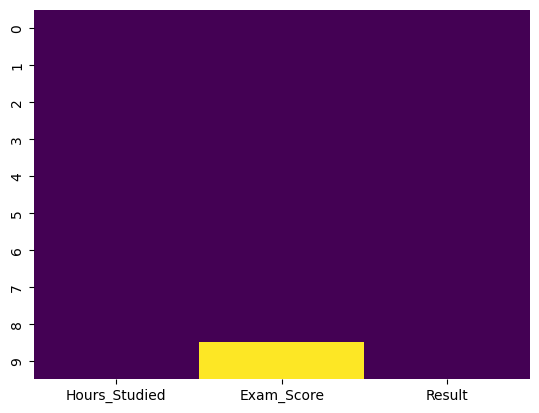

In [8]:
# heatmap to visualize missing values
sns.heatmap(records.isnull(), cbar=False, cmap='viridis')

In [9]:
# remove rows with missing values
records.dropna(inplace=True)

In [10]:
# fill the na values with the mean of the column
records["Exam_Score"] = records['Exam_Score'].fillna(records['Exam_Score'].mean(), inplace=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_21988\2161431848.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  records["Exam_Score"] = records['Exam_Score'].fillna(records['Exam_Score'].mean(), inplace=True)


In [11]:
records["Exam_Score"]

0    10.0
1    20.0
2    30.0
3    40.0
4    50.0
5    60.0
6    70.0
7    80.0
8    90.0
Name: Exam_Score, dtype: float64

In [12]:
# convert the target variable to binary
records['Result'] = records['Result'].map({'pass': 1, 'fail': 0})

In [13]:
records.head()

,Hours_Studied,Exam_Score,Result
0,1,10.0,0
1,2,20.0,0
2,3,30.0,0
3,4,40.0,0
4,5,50.0,1


<Axes: >

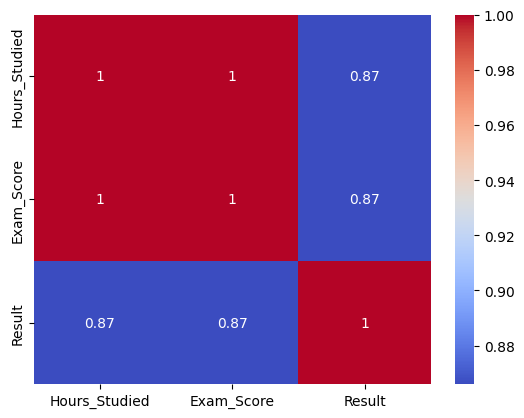

In [14]:
# HEATMAP TO VISUALIZE THE CORRELATION BETWEEN THE FEATURES AND THE TARGET VARIABLE
sns.heatmap(records.corr(), annot=True, cmap='coolwarm')

In [15]:
# train test split
X = records[['Hours_Studied', 'Exam_Score']]
y = records['Result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
X_train.head()

,Hours_Studied,Exam_Score
5,6,60.0
0,1,10.0
8,9,90.0
2,3,30.0
4,5,50.0


In [17]:
X_test.head()

,Hours_Studied,Exam_Score
7,8,80.0
1,2,20.0


In [18]:
y_train

5    1
0    0
8    1
2    0
4    1
3    0
6    1
Name: Result, dtype: int64

In [19]:
y_test

7    1
1    0
Name: Result, dtype: int64

In [20]:
# model training
model = LogisticRegression()

In [21]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [22]:
# confiusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))

[[1 0]
 [0 1]]


In [23]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



<Axes: >

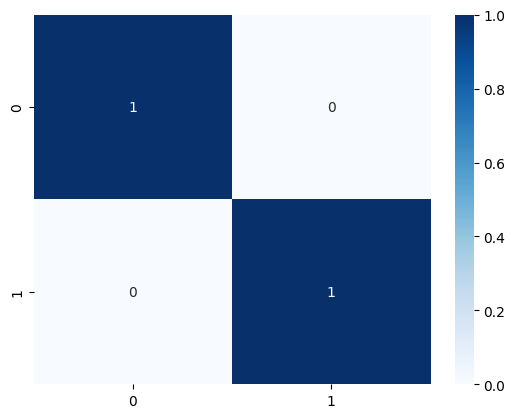

In [24]:
# heatmap to visualize the confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')

In [25]:
# save the model for future use
import joblib
joblib.dump(model, 'model.pkl')

['model.pkl']